# Forecast Season — July Issues 2023–2026 (Flood & Flashflood)
เทียบ forecast report เดือน 7 (July issue) ของปี 2023–2026 ที่ Tambon level:
1. load 4 forecast files + clean tambon geojson
2. data check — schema แต่ละปีไม่เหมือนกัน
3. harmonize — relabel `inundation` → `flood risk` (ไฟล์ 2023)
4. check `TAMBON_IDN` vs `ADM3_PCODE` — join key ตรงกันแค่ไหน
5. fix mismatch
6. take max ราย Tambon — โดน flag ≥1 เดือนใน 6 เดือน = `risk`
7. analysis — จำนวนรายปี / year-over-year change / persistence / province change, แยก flood / flashflood
8. output geojson → tableau

## Load data

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

FORECAST_DIR = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/Flood Forecast 6 month')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/TH_TAMBON_json/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')
YEARS = [2023, 2024, 2025, 2026]

forecasts = {year: pd.read_excel(FORECAST_DIR / f'{year}07FloodForecast_6month.xlsx') for year in YEARS}
shapes = gpd.read_file(SHAPE_PATH)

for year in YEARS:
    print(f'{year}07 rows:', len(forecasts[year]))
print('Tambon polygons:', len(shapes))

202307 rows: 44322
202407 rows: 44328
202507 rows: 44328
202607 rows: 44328
Tambon polygons: 7425


## Data check
- เช็ค field / เดือน / TYPE_E ของแต่ละไฟล์ก่อน — เทียบ columns กับไฟล์ 2026 (ตัวล่าสุด)

In [2]:
ref_cols = list(forecasts[2026].columns)
print('2026 columns:', ref_cols)
print()

for year in YEARS:
    df = forecasts[year]
    dup = df.loc[df.duplicated(['TAMBON_IDN', 'MONTH']), 'TAMBON_IDN'].unique()
    missing = [col for col in ref_cols if col not in df.columns]
    print(f'=== {year}07 ===')
    print('months:', sorted(df['MONTH'].unique()),
          '| unique tambons:', df['TAMBON_IDN'].nunique(),
          '| duplicated tambon in a month:', list(dup) if len(dup) else '-')
    print('missing columns vs 2026:', missing if missing else '-')
    print(df['TYPE_E'].value_counts().to_string())
    print()

2026 columns: ['TAMBON_IDN', 'TAMBON_T', 'TAMBON_E', 'AMPHOE_IDN', 'AMPHOE_T', 'AMPHOE_E', 'PROV_CODE', 'PROV_T', 'PROV_E', 'REGION_CODE', 'REGION', 'TYPE_T', 'TYPE_E', 'YEAR', 'MONTH']

=== 202307 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | duplicated tambon in a month: -
missing columns vs 2026: ['TAMBON_E', 'AMPHOE_E', 'PROV_E', 'REGION_CODE', 'REGION']
TYPE_E
norisk        37618
inundation     5111
flashflood     1593

=== 202407 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | duplicated tambon in a month: [np.int64(200701)]
missing columns vs 2026: ['REGION_CODE', 'REGION']
TYPE_E
norisk        35138
flood risk     6486
flashflood     2704

=== 202507 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | duplicated tambon in a month: [np.int64(200701)]
missing columns vs 20

## Harmonize

- key `TAMBON_IDN` (7,387 tambons × 6 เดือน)
- 2023: ไม่มี columns ภาษาอังกฤษ (`TAMBON_E`/`AMPHOE_E`/`PROV_E`) และ flood ใช้ label `inundation` (เปลี่ยนเป็น `flood risk` ตั้งแต่ไฟล์ 202406)
- 2024–2026: tambon `200701` ซ้ำ 2 แถวต่อเดือน → เดี๋ยว take max ด้วย groupby จัดการให้

→ relabel `inundation` → `flood risk` + สร้าง `CODE` เป็น string ให้ทุกปีหน้าตาเดียวกัน

In [3]:
for df in forecasts.values():
    df['TYPE_E'] = df['TYPE_E'].replace({'inundation': 'flood risk'})
    df['CODE'] = df['TAMBON_IDN'].astype(str)

print('TYPE_E after relabel:')
for year in YEARS:
    print(f'  {year} ->', sorted(forecasts[year]['TYPE_E'].unique()))

TYPE_E after relabel:
  2023 -> ['flashflood', 'flood risk', 'norisk']
  2024 -> ['flashflood', 'flood risk', 'norisk']
  2025 -> ['flashflood', 'flood risk', 'norisk']
  2026 -> ['flashflood', 'flood risk', 'norisk']


## Check TAMBON_IDN vs ADM3_PCODE
- เทียบ code กับ shapes (ตัด prefix TH) ว่า join แล้วตรงกันแค่ไหน ตรงไหนหาย + เช็คทุกปี

In [4]:
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')
shape_codes = set(shapes['CODE'])

orphan_codes = set()
for year in YEARS:
    codes = set(forecasts[year]['CODE'])
    orphans = sorted(codes - shape_codes)
    orphan_codes |= set(orphans)
    print(f'{year}07 matched: {len(codes & shape_codes)} | only in forecast: {orphans}')

202307 matched: 7381 | only in forecast: ['201201', '401050', '530407', '630191', '810150', '860805']
202407 matched: 7381 | only in forecast: ['201201', '401050', '530407', '630191', '810150', '860805']
202507 matched: 7381 | only in forecast: ['201201', '401050', '530407', '630191', '810150', '860805']
202607 matched: 7381 | only in forecast: ['201201', '401050', '530407', '630191', '810150', '860805']


## Fix mismatch
ทำเหมือนเดิมเลย คือ
- orphan 6 codes **เหมือนกันทุกปี** → remap ครั้งเดียวใช้ได้ทั้ง 4 ปี: ไปตำบล code ใกล้สุดในอำเภอเดียวกัน (วิธีเดียวกับ `6monthforecast.ipynb`)
- ไฟล์ 2023 ไม่มี `AMPHOE_E` → match อำเภอด้วยชื่อไทย `AMPHOE_T` vs `ADM2_TH` แทน (จำกัดจังหวัดเดียวกันด้วย 2 หลักแรกของ code)
- codes ที่มีแต่ใน shapes ไม่ต้องทำอะไร — จะกลายเป็น no risk ตอน merge

In [5]:
def nearest_shape_code(row):
    same_amphoe = shapes.loc[(shapes['CODE'].str[:2] == row['CODE'][:2])
                             & (shapes['ADM2_TH'] == row['AMPHOE_T']), 'CODE']
    last2 = int(row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - last2))


orphans = forecasts[2026][forecasts[2026]['CODE'].isin(orphan_codes)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}
for df in forecasts.values():
    df['CODE'] = df['CODE'].replace(remap)

print('Re-mapped orphan forecast codes (all years):')
for old, new in remap.items():
    print(f'  {old} -> {new}')

Re-mapped orphan forecast codes (all years):
  201201 -> 200401
  401050 -> 401017
  530407 -> 530406
  630191 -> 630115
  810150 -> 810118
  860805 -> 860804


## Take max ราย Tambon
- แต่ละปี: tambon ไหนโดน flag ≥1 เดือน (ใน 6 เดือน) = `risk` — แยก flood / flashflood
- groupby `CODE` + `any()` → จัดการทั้ง tambon ซ้ำ (`200701`) และ code ที่ remap มาชนกันในตัว
- ได้ตาราง wide: row = tambon, column = ปี, ค่า = risk (True/False)

In [6]:
def take_max(df, type_label):
    return df.assign(flag=df['TYPE_E'].eq(type_label)).groupby('CODE')['flag'].any()


flood_wide = pd.DataFrame({year: take_max(forecasts[year], 'flood risk') for year in YEARS}).fillna(False)
flash_wide = pd.DataFrame({year: take_max(forecasts[year], 'flashflood') for year in YEARS}).fillna(False)

print('Tambons:', len(flood_wide))
flood_wide.head()

Tambons: 7381


,2023,2024,2025,2026
CODE,,,,
100101,False,False,False,False
100102,False,False,False,False
100103,False,False,False,False
100104,False,False,False,False
100105,False,False,False,False


## Analysis 1 — จำนวนตำบล risk รายปี
- ภาพรวมก่อน: แต่ละ month 7 issue มีตำบล risk กี่ตำบล

      flood  flashflood
YEAR                   
2023   3128         912
2024   3624        1210
2025   2932         709
2026   2180         558


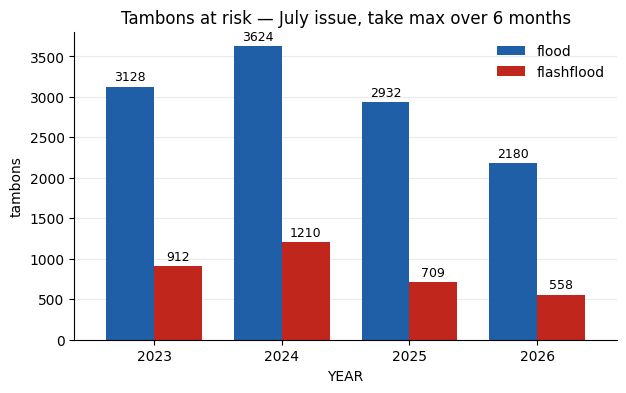

In [7]:
import matplotlib.pyplot as plt

FLOOD_COLOR, FLASH_COLOR = '#1F5FA8', '#C0261B'

counts = pd.DataFrame({'flood': flood_wide.sum(), 'flashflood': flash_wide.sum()})
counts.index.name = 'YEAR'
print(counts.to_string())

ax = counts.plot.bar(color=[FLOOD_COLOR, FLASH_COLOR], figsize=(7, 4), width=0.75, rot=0)
ax.set_title('Tambons at risk — July issue, take max over 6 months')
ax.set_ylabel('tambons')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
ax.legend(frameon=False)

## Analysis 2 — Year-over-year change
- `added` = ปีนี้ risk แต่ปีก่อนไม่, `removed` = ปีก่อน risk แต่ปีนี้หลุด, `stayed` = risk ทั้งสองปี

In [8]:
def yoy_change(wide):
    rows = []
    for prev, cur in zip(YEARS, YEARS[1:]):
        rows.append({'change': f'{prev} -> {cur}',
                     'added': int((~wide[prev] & wide[cur]).sum()),
                     'removed': int((wide[prev] & ~wide[cur]).sum()),
                     'stayed': int((wide[prev] & wide[cur]).sum())})
    return pd.DataFrame(rows).set_index('change')


print('=== Flood ===')
print(yoy_change(flood_wide).to_string())
print()
print('=== Flashflood ===')
print(yoy_change(flash_wide).to_string())

=== Flood ===
              added  removed  stayed
change                              
2023 -> 2024   1124      628    2500
2024 -> 2025    682     1374    2250
2025 -> 2026    422     1174    1758

=== Flashflood ===
              added  removed  stayed
change                              
2023 -> 2024    316       18     894
2024 -> 2025     41      542     668
2025 -> 2026     95      246     463


## Analysis 3 — Persistence: โดนกี่ปีใน 4 ปี
- `YEARS_AT_RISK` = จำนวนปี (0–4) ที่ tambon โดน flag — ดูว่า risk ซ้ำที่เดิมแค่ไหน

In [9]:
persistence = pd.DataFrame({'flood': flood_wide.sum(axis=1), 'flashflood': flash_wide.sum(axis=1)})

summary = pd.DataFrame({col: persistence[col].value_counts() for col in persistence})
summary = summary.reindex(range(5), fill_value=0)
summary.index.name = 'YEARS_AT_RISK'
print(summary.to_string())

               flood  flashflood
YEARS_AT_RISK                   
0               2682        6100
1               1335         236
2               1105         389
3                717         249
4               1542         407


## Analysis 4 — จังหวัดไหนเปลี่ยนมากสุด (2023 vs 2026)
- net change รายจังหวัด: จำนวนตำบล risk ปี 2026 ลบปี 2023 — ดูว่าความเสี่ยงย้ายไปโซนไหน

In [10]:
code_to_prov = shapes.set_index('CODE')['ADM1_EN']


def province_change(wide, label):
    by_prov = wide.groupby(code_to_prov).sum()
    change = (by_prov[2026] - by_prov[2023]).sort_values()
    print(f'=== {label} — top increase ===')
    print(change.tail(5)[::-1].to_string())
    print(f'--- top decrease ---')
    print(change.head(5).to_string())
    print()


province_change(flood_wide, 'Flood')
province_change(flash_wide, 'Flashflood')

=== Flood — top increase ===
ADM1_EN
Nakhon Ratchasima    44
Buri Ram             21
Songkhla             16
Narathiwat           14
Phatthalung          14
--- top decrease ---
ADM1_EN
Khon Kaen       -86
Si Sa Ket       -72
Ratchaburi      -67
Udon Thani      -61
Nakhon Pathom   -56

=== Flashflood — top increase ===
ADM1_EN
Trat            8
Narathiwat      6
Nakhon Nayok    5
Tak             4
Phitsanulok     3
--- top decrease ---
ADM1_EN
Chiang Mai   -42
Chiang Rai   -38
Phrae        -37
Lampang      -36
Loei         -34



## Maps — risk รายปี
- take max: `risk` = สีเข้ม, `no risk` = เทา; flood = น้ำเงิน, flashflood = แดง (โทนเดียวกับ `6monthforecast.ipynb`)

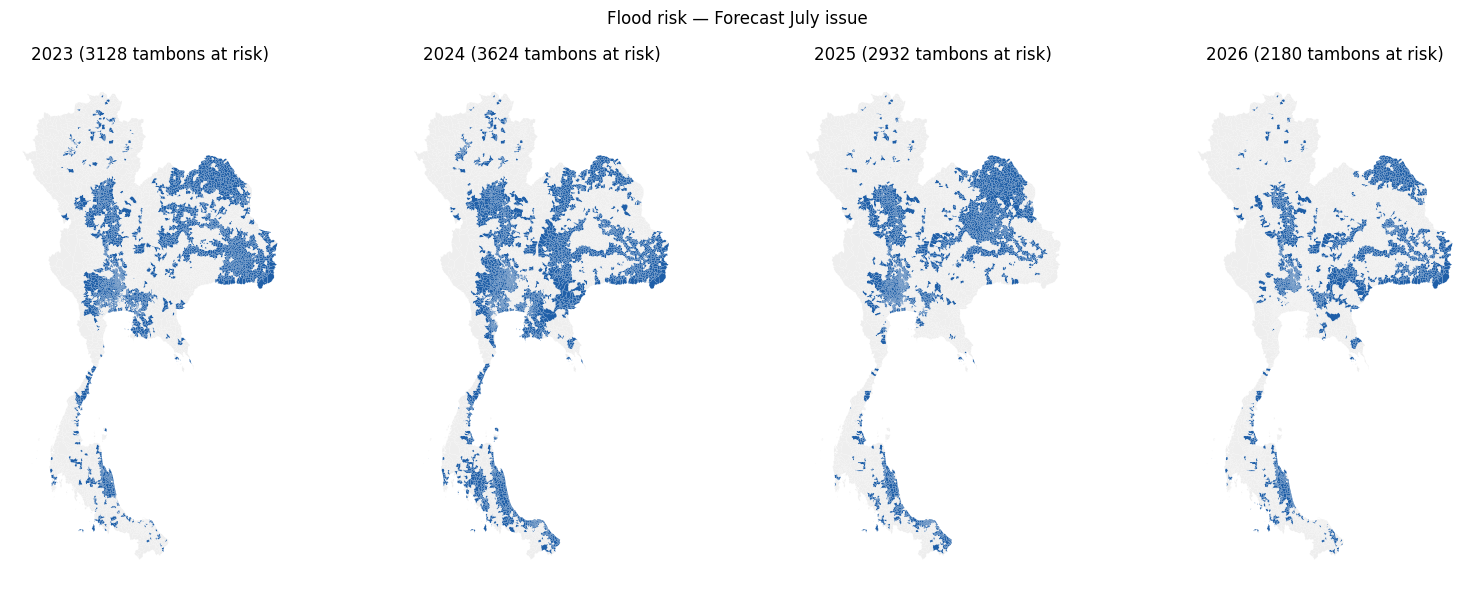

In [18]:
NO_RISK_COLOR = '#EEEEEE'


def plot_years(wide, risk_color, title):
    fig, axes = plt.subplots(1, 4, figsize=(16, 6))
    for ax, year in zip(axes, YEARS):
        layer = shapes.assign(RISK=shapes['CODE'].map(wide[year]).eq(True))
        layer.plot(ax=ax, color=layer['RISK'].map({True: risk_color, False: NO_RISK_COLOR}),
                   edgecolor='white', linewidth=0.05)
        ax.set_title(f'{year} ({int(wide[year].sum())} tambons at risk)')
        ax.axis('off')
    fig.suptitle(title, y=0.98)
    fig.tight_layout()


plot_years(flood_wide, FLOOD_COLOR, 'Flood risk — Forecast July issue')

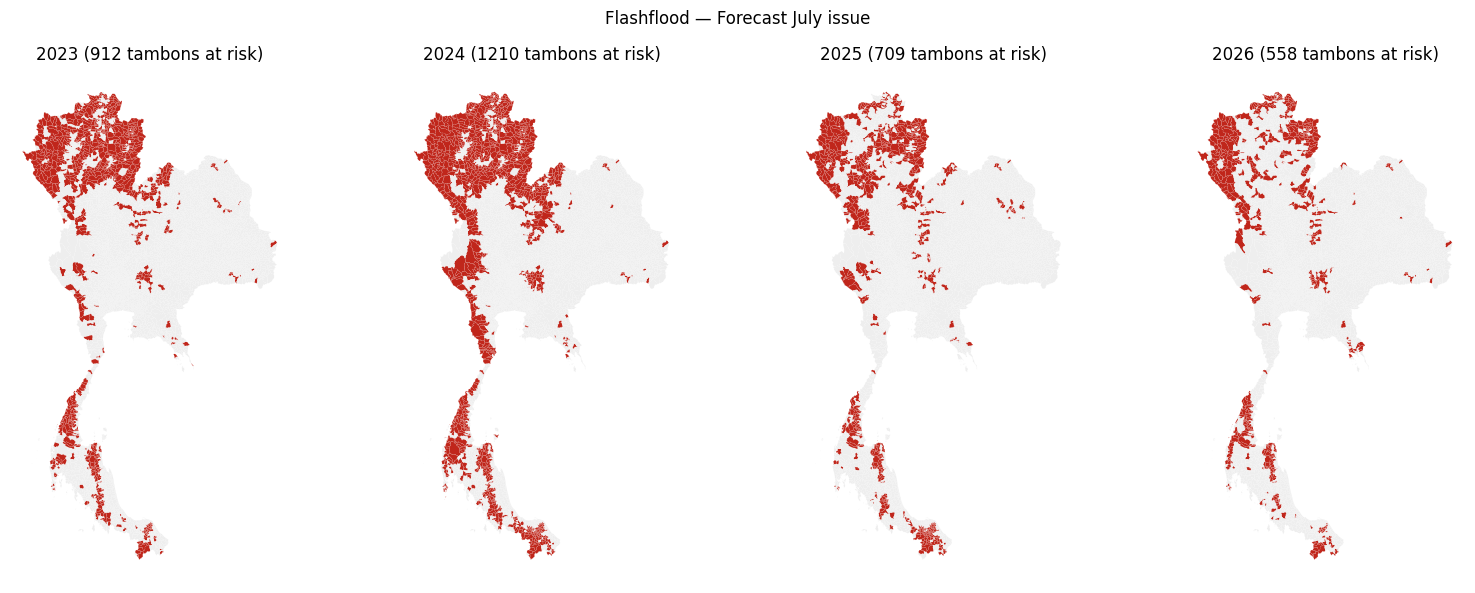

In [19]:
plot_years(flash_wide, FLASH_COLOR, 'Flashflood — Forecast July issue')

## Maps — persistence
- สี light→dark ตามจำนวนปีที่โดน flag (0–4) — โซนสีเข้ม = risk ซ้ำทุกปี

<Axes: title={'center': 'Flood risk — years flagged, 2023–2026'}>

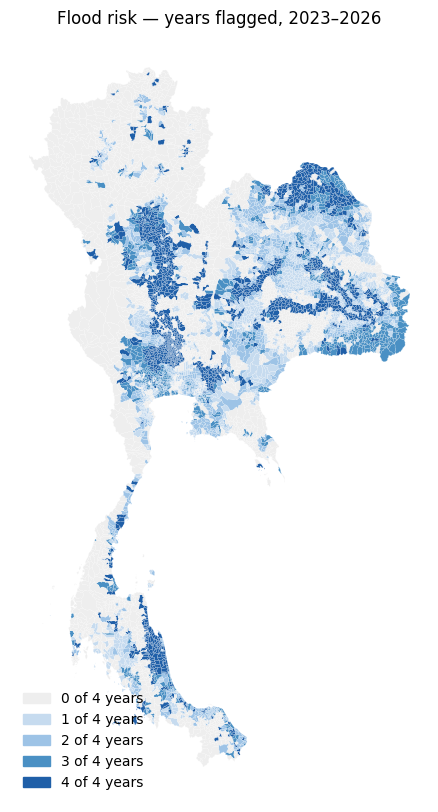

In [16]:
from matplotlib.patches import Patch

FLOOD_RAMP = {0: '#EEEEEE', 1: '#C6DBEF', 2: '#9DC3E6', 3: '#4A90C4', 4: '#1F5FA8'}
FLASH_RAMP = {0: '#EEEEEE', 1: '#FDD0A2', 2: '#F4A582', 3: '#D6604D', 4: '#C0261B'}


def plot_persistence(col, ramp, title):
    layer = shapes.merge(persistence[col].rename('N_YEARS'), left_on='CODE', right_index=True, how='left')
    layer['N_YEARS'] = layer['N_YEARS'].fillna(0).astype(int)
    ax = layer.plot(color=layer['N_YEARS'].map(ramp), figsize=(8, 10), edgecolor='white', linewidth=0.1)
    ax.set_title(title)
    ax.axis('off')
    ax.legend(handles=[Patch(color=color, label=f'{n} of 4 years') for n, color in ramp.items()],
              loc='lower left', frameon=False)
    return ax


plot_persistence('flood', FLOOD_RAMP, 'Flood risk — years flagged, 2023–2026')

<Axes: title={'center': 'Flashflood — years flagged, 2023–2026'}>

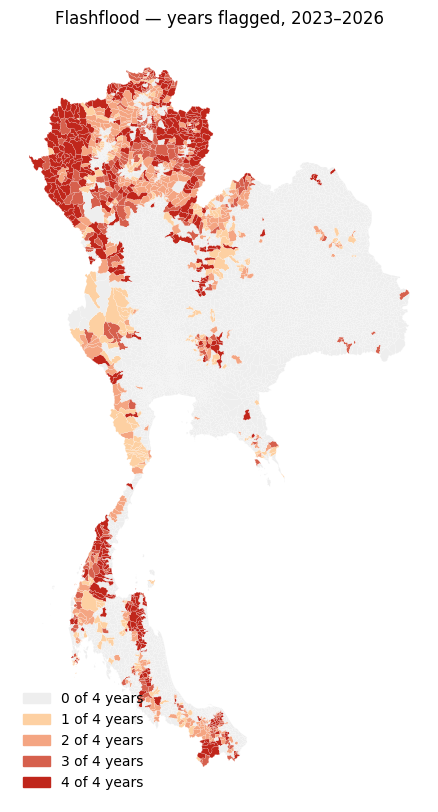

In [17]:
plot_persistence('flashflood', FLASH_RAMP, 'Flashflood — years flagged, 2023–2026')

## Output geojson
- one file per type: `RISK_2023`..`RISK_2026` (`risk` / `no risk`) + `YEARS_AT_RISK` → tableau

In [15]:
def save_geojson(wide, years_at_risk, path):
    layer = shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN', 'CODE', 'geometry']].copy()
    for year in YEARS:
        risk = layer['CODE'].map(wide[year]).eq(True)
        layer[f'RISK_{year}'] = risk.map({True: 'risk', False: 'no risk'})
    layer['YEARS_AT_RISK'] = layer['CODE'].map(years_at_risk).fillna(0).astype(int)
    layer = layer.drop(columns='CODE')
    layer.to_file(path, driver='GeoJSON', COORDINATE_PRECISION=8)
    print('Saved', len(layer), 'features to', path, f'({path.stat().st_size / 1e6:.1f} MB)')


save_geojson(flood_wide, persistence['flood'], OUTPUT_PATH / 'season07_flood_risk.geojson')
save_geojson(flash_wide, persistence['flashflood'], OUTPUT_PATH / 'season07_flashflood_risk.geojson')

Saved 7425 features to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/season07_flood_risk.geojson (8.8 MB)


Saved 7425 features to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/season07_flashflood_risk.geojson (8.9 MB)
